Saving Budget_Survey_2020_20260308.csv to Budget_Survey_2020_20260308 (7).csv


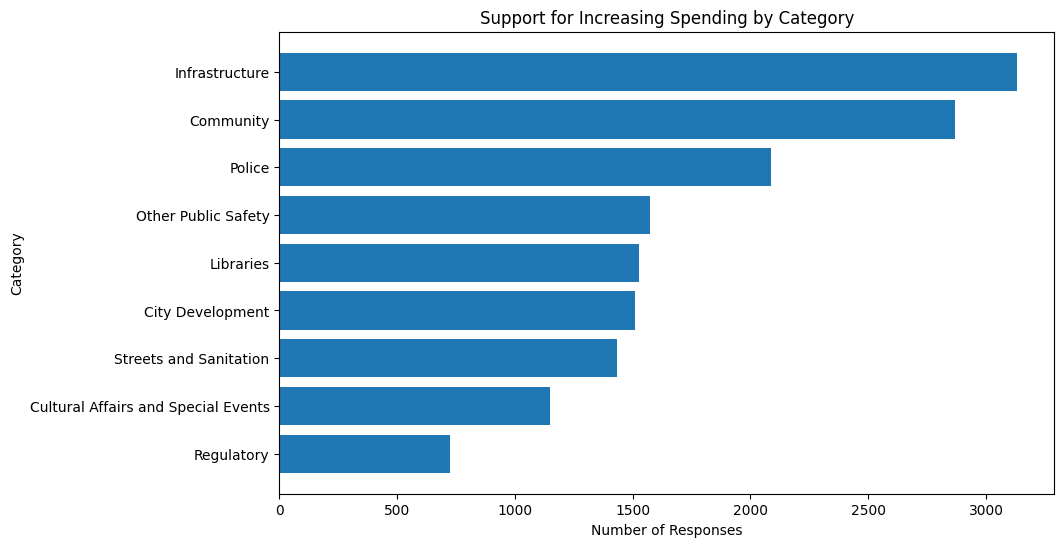

<Figure size 640x480 with 0 Axes>

In [9]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

df = pd.read_csv("Budget_Survey_2020_20260308.csv")
df.head()

spending_cols = [col for col in df.columns if "Spending Change -" in col]
spending_cols

spending_summary = pd.DataFrame()

for col in spending_cols:
    counts = df[col].value_counts(dropna=False)
    spending_summary.loc[col, "Increase Budget"] = counts.get("Increase Budget", 0)
    spending_summary.loc[col, "Keep Budget the Same"] = counts.get("Keep Budget the Same", 0)
    spending_summary.loc[col, "Reduce Budget"] = counts.get("Reduce Budget", 0)

spending_summary = spending_summary.reset_index().rename(columns={"index": "Category"})
spending_summary


spending_summary["Category"] = spending_summary["Category"].str.replace("Spending Change - ", "", regex=False)
spending_summary



revenue_cols = [col for col in df.columns if "Revenue Change -" in col]

revenue_summary = pd.DataFrame()

for col in revenue_cols:
    counts = df[col].value_counts(dropna=False)
    revenue_summary.loc[col, "No Opinion"] = counts.get("No Opinion", 0)
    revenue_summary.loc[col, "Increase Tax or Fee"] = counts.get("Increase Tax or Fee", 0)
    revenue_summary.loc[col, "Keep Tax or Fee the Same"] = counts.get("Keep Tax or Fee the Same", 0)

revenue_summary = revenue_summary.reset_index().rename(columns={"index": "Category"})
revenue_summary["Category"] = revenue_summary["Category"].str.replace("Revenue Change - ", "", regex=False)

revenue_summary


import matplotlib.pyplot as plt

spending_plot = spending_summary.sort_values("Increase Budget", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(spending_plot["Category"], spending_plot["Increase Budget"])
plt.xlabel("Number of Responses")
plt.ylabel("Category")
plt.title("Support for Increasing Spending by Category")
plt.gca().invert_yaxis()
plt.show()

plt.savefig("spending_increase_chart.png", bbox_inches="tight")

